In [1]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report,f1_score,roc_curve,roc_auc_score
from sklearn.ensemble import RandomForestClassifier



In [ ]:
#Load the processed datsaset
df_encoded = pd.read_csv("../Data/Processed/encoded_data.csv/")

In [4]:
#Define the target variable and features for the model
x = df_encoded.drop(columns ='isFraud')
y = df_encoded['isFraud']

In [5]:
#Train test split dataset
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

## Initialize and examine how well the Random Forest baseline performed

In [6]:
#Train a Random Forest Classifier as our baseline. The class_weight parameter is set to 'balanced' to handle the class imbalance of fraud vs. non-fraud in the dataset.
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

confusion = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Confusion Matrix \n", confusion)
print("\nClassification Report\n", class_report)


Confusion Matrix 
 [[1270749     155]
 [    470    1150]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.88      0.71      0.79      1620

    accuracy                           1.00   1272524
   macro avg       0.94      0.85      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524



The f1_score is the metric we are highlighting to measure the performance of our model. The f1_score is a measure of a test's accuracy and is defined as the mean of precision and recall. It is particularly useful when the class distribution is imbalanced, which is the case within this dataset. In our Classification Report, the f1_score of classifying transactions as fraud is pretty high of .79. In the Confusion Matrix, 470 is the amount of transactions that were not captured as fraud but were fraud aka False Negative is 470. Once putting 470 transcations into perspective, this is an amount we want to continue to make efforts to reduce. By optimizing for the F1 score, we can ensure that our model effectively identifies fraudulent transactions while minimizing false positives and false negatives.

#Now, let's see if we can beat our F1 score with Hyperparameter Tuning: RandomizedSearchCV 

In [7]:
param_grid = {
    "max_depth": [10, 20],
    "min_samples_split":[2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ["sqrt", "log2"],
    "n_estimators": [100, 200]
}
random_search= RandomizedSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    random_state=42,
    scoring='f1',
    n_jobs=-1

)
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [10, 20], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versi

In [8]:
print("Best Hyperparameters: ", random_search.best_params_)
print ("Best F1 Score: ", random_search.best_score_)


Best Hyperparameters:  {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Best F1 Score:  0.245080761050704


In [9]:
#After the hyperparameter tuning, I will update the parameters of the model by those which are obtained by using RandomizedSearchCV. 

best_rf = RandomForestClassifier(random_state=42, 
                                 class_weight='balanced', 
                                n_estimators=100, 
                                min_samples_split=5, 
                                min_samples_leaf=2, 
                                max_features='log2',
                                max_depth=20)

best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

hype_confusion = confusion_matrix(y_test, y_pred_best)
hype_class_report = classification_report(y_test, y_pred_best)

print("Confusion Matrix \n", hype_confusion)
print("\nClassification Report\n", hype_class_report)


Confusion Matrix 
 [[1257137   13767]
 [    244    1376]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270904
           1       0.09      0.85      0.16      1620

    accuracy                           0.99   1272524
   macro avg       0.55      0.92      0.58   1272524
weighted avg       1.00      0.99      0.99   1272524



The f1 score did decrease to .16. The breakdown of the the confusion matrix is as follows: a higher recall vs precision. This means that the model is better at identifying true positives (fraud cases) but also has a higher number of false positives (non-fraud cases incorrectly classified as fraud). Depending on the specific requirements of the fraud detection task, this trade-off may be acceptable or may require further tuning to balance precision and recall more effectively.Let's provide context to the numbers. The bank has a higher rate of correctly classifying fraud alerts (high recall) but has increased the number of false alarm transactions as fraud. This is a tradeoff that the bank may take given that the client is simply notified via text to dislarm the false "fraud alert" vs a fraudulent transaction actually getting away.  

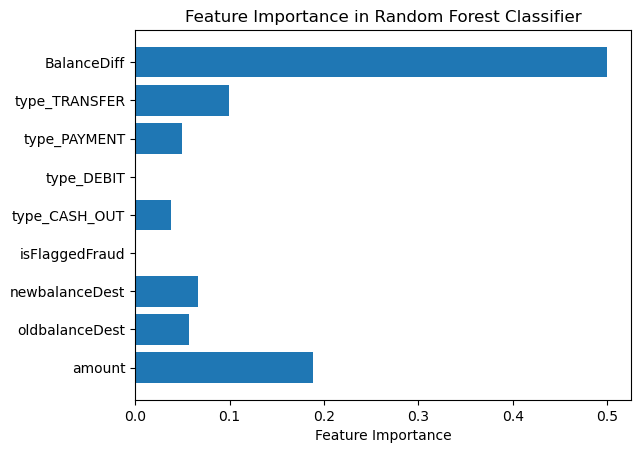

In [11]:
feature_importances = best_rf.feature_importances_

plt.barh(X_train.columns, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

In [ ]:
#ROC Curve/ AUC Score 
# calculate specificity by hand


tn, fp, fn, tp = confusion.ravel()
specificity = tn / (tn + fp)
print(f"Specificity: {specificity:.2f}")

Specificity: 1.00


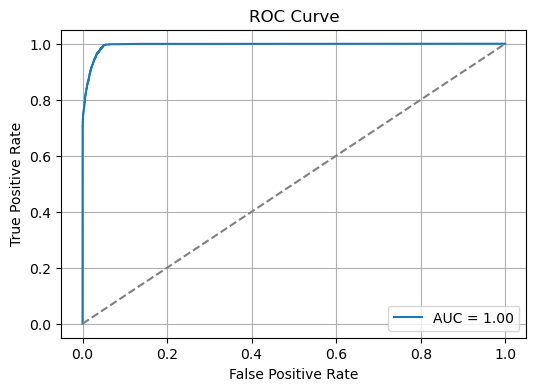

In [16]:
# get probability scores for ROC curve
y_probs = best_rf.predict_proba(X_test)[:, 1]

# generate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

# Plotting
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

